# Caso real: precificação

**Tema:** Aprendizado Supervisionado › Regressão Linear

Um problema completo, ponta a ponta: prever o preço de venda de imóveis a
partir de características físicas e de localização — com a preparação de
dados do tema 3 aplicada de verdade (não como formalidade), diagnóstico do
notebook anterior, e interpretação de coeficientes no fim.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

rng = np.random.default_rng(50)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
AZUL, VERDE, VERMELHO, ROXO, AMBAR = "#1F5C8B", "#1E6B4F", "#9C2B2B", "#5B3E86", "#8A6100"
print("pronto")

pronto


## 1. Simulando um dataset de imóveis com os defeitos usuais do tema 3

In [2]:
n = 3000
area_m2 = rng.gamma(6, 20, n).clip(25, None)
quartos = rng.integers(1, 6, n)
idade_anos = rng.exponential(12, n).clip(0, 60)
distancia_centro_km = rng.exponential(8, n).clip(0.2, 40)
bairro = rng.choice(["Centro", "Zona Sul", "Zona Norte", "Zona Leste", "Zona Oeste"],
                    n, p=[0.10, 0.30, 0.25, 0.20, 0.15])

# preço com relação NÃO totalmente linear (log-área) e ruído multiplicativo
premio_bairro = {"Centro": 1.15, "Zona Sul": 1.35, "Zona Norte": 0.95,
                 "Zona Leste": 0.85, "Zona Oeste": 1.05}
preco_base = (
    3200 * area_m2
    + 18000 * quartos
    - 1500 * idade_anos
    - 4000 * distancia_centro_km
)
preco = (preco_base * np.array([premio_bairro[b] for b in bairro])
        * rng.lognormal(0, 0.12, n)).clip(60000, None)

df = pd.DataFrame({
    "area_m2": area_m2.round(1), "quartos": quartos, "idade_anos": idade_anos.round(1),
    "distancia_centro_km": distancia_centro_km.round(2), "bairro": bairro,
    "preco": preco.round(2),
})
# nulos MAR (imóveis mais antigos têm mais dados de idade faltando no cadastro)
prob_nulo = 0.03 + 0.15 * (df["idade_anos"] > 30)
df.loc[rng.random(n) < prob_nulo, "idade_anos"] = np.nan

print(df.shape)
df.head()

(3000, 6)


,area_m2,quartos,idade_anos,distancia_centro_km,bairro,preco
0,138.1,3,2.6,2.31,Zona Oeste,520312.35
1,148.3,4,4.8,0.31,Zona Oeste,485739.52
2,212.6,4,9.5,1.72,Zona Leste,584550.68
3,140.7,5,14.0,8.05,Zona Sul,666790.16
4,125.4,5,11.3,8.97,Zona Leste,367127.90


## 2. Split treino/teste ANTES de qualquer preparo (tema 3)

In [3]:
X = df.drop(columns="preco")
y = df["preco"]
X_treino, X_teste, y_treino, y_teste = train_test_split(X, y, test_size=0.25, random_state=0)

colunas_numericas = ["area_m2", "quartos", "idade_anos", "distancia_centro_km"]
colunas_categoricas = ["bairro"]

pre_processador = ColumnTransformer([
    ("numericas", Pipeline([
        ("imputa", SimpleImputer(strategy="median")),
        ("escalona", StandardScaler()),
    ]), colunas_numericas),
    ("categoricas", OneHotEncoder(drop="first"), colunas_categoricas),
])

pipeline = Pipeline([("preparo", pre_processador), ("modelo", LinearRegression())])
pipeline.fit(X_treino, y_treino)

pred_teste = pipeline.predict(X_teste)
print(f"MAE : {mean_absolute_error(y_teste, pred_teste):,.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_teste, pred_teste)):,.2f}")
print(f"R²  : {r2_score(y_teste, pred_teste):.4f}")

MAE : 51,137.39
RMSE: 67,484.23
R²  : 0.8936


## 3. Diagnosticando o modelo — o alvo pede transformação?

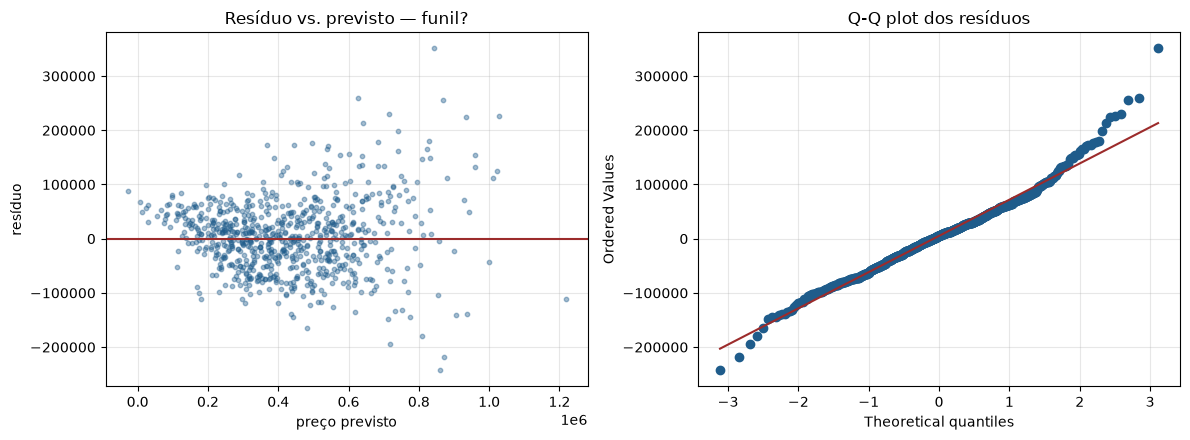

In [4]:
residuos_teste = y_teste - pred_teste

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].scatter(pred_teste, residuos_teste, s=10, alpha=0.4, color=AZUL)
axes[0].axhline(0, color=VERMELHO, lw=1.5)
axes[0].set_xlabel("preço previsto"); axes[0].set_ylabel("resíduo")
axes[0].set_title("Resíduo vs. previsto — funil?")

stats.probplot(residuos_teste, dist="norm", plot=axes[1])
axes[1].get_lines()[0].set_color(AZUL)
axes[1].get_lines()[1].set_color(VERMELHO)
axes[1].set_title("Q-Q plot dos resíduos")
plt.tight_layout(); plt.show()

**Se aparecer heterocedasticidade** (funil crescendo com o preço previsto —
comum em preços, que têm variância proporcional ao nível, não constante),
o candidato natural é modelar `log(preco)` em vez de `preco`. Vamos medir a
heterocedasticidade diretamente e comparar os dois modelos — sem assumir de
antemão qual vai vencer.

correlação entre |resíduo| e valor previsto: 0.371
(correlação positiva e não-trivial: HÁ heterocedasticidade real aqui —
 o funil do painel acima não é imaginação.)

fator de correção de smearing (deveria ser > 1): 1.0149

modelo                                      MAE           RMSE       R²
------------------------------------------------------------------------
preço bruto                           51,137.39      67,484.23   0.8936
log(preço), exp() ingênuo             61,378.53     100,822.99   0.7626
log(preço), c/ correção smearing      60,871.98     102,145.03   0.7563


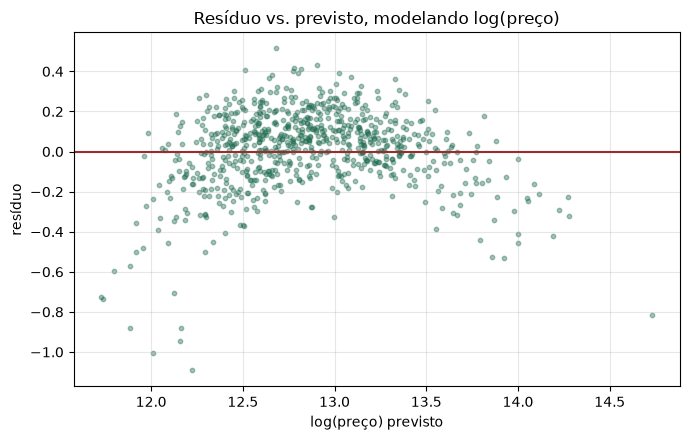

In [5]:
correlacao_residuo_previsto = np.corrcoef(np.abs(residuos_teste), pred_teste)[0, 1]
print(f"correlação entre |resíduo| e valor previsto: {correlacao_residuo_previsto:.3f}")
print("(correlação positiva e não-trivial: HÁ heterocedasticidade real aqui —")
print(" o funil do painel acima não é imaginação.)")

y_treino_log = np.log(y_treino)
y_teste_log = np.log(y_teste)

pipeline_log = Pipeline([("preparo", pre_processador), ("modelo", LinearRegression())])
pipeline_log.fit(X_treino, y_treino_log)
pred_teste_log = pipeline_log.predict(X_teste)

# Retransformar exp(previsão) SUBESTIMA sistematicamente a média (a mediana da
# log-normal é menor que a média) -- o "smearing estimator" de Duan corrige
# isso multiplicando por um fator estimado no TREINO, nunca no teste.
residuos_treino_log = y_treino_log - pipeline_log.predict(X_treino)
fator_smearing = np.mean(np.exp(residuos_treino_log))
pred_log_ingenua = np.exp(pred_teste_log)
pred_log_corrigida = pred_log_ingenua * fator_smearing

print(f"\nfator de correção de smearing (deveria ser > 1): {fator_smearing:.4f}")

print(f"\n{'modelo':<32s} {'MAE':>14s} {'RMSE':>14s} {'R²':>8s}")
print("-" * 72)
for nome, pred in [("preço bruto", pred_teste),
                   ("log(preço), exp() ingênuo", pred_log_ingenua),
                   ("log(preço), c/ correção smearing", pred_log_corrigida)]:
    print(f"{nome:<32s} {mean_absolute_error(y_teste, pred):>14,.2f} "
          f"{np.sqrt(mean_squared_error(y_teste, pred)):>14,.2f} "
          f"{r2_score(y_teste, pred):>8.4f}")

residuos_log = y_teste_log - pred_teste_log
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.scatter(pred_teste_log, residuos_log, s=10, alpha=0.4, color=VERDE)
ax.axhline(0, color=VERMELHO, lw=1.5)
ax.set_xlabel("log(preço) previsto"); ax.set_ylabel("resíduo")
ax.set_title("Resíduo vs. previsto, modelando log(preço)")
plt.tight_layout(); plt.show()

**O resultado honesto neste dataset: o modelo em log NÃO venceu**, apesar
da heterocedasticidade real detectada acima — mesmo depois de corrigir o
viés de retransformação. A explicação é que o processo gerador aqui é
aproximadamente **linear no preço** (a simulação soma termos em reais), não
no log do preço; log-transformar troca um problema (heterocedasticidade)
por outro (a relação deixa de ser linear no espaço transformado). A lição
não é "nunca use log" — é que **heterocedasticidade sozinha não garante que
transformar o alvo vai melhorar o modelo**: sempre valide empiricamente,
como fizemos aqui, em vez de aplicar a transformação por reflexo.

> **De onde vem o viés de retransformação:** para uma variável log-normal,
> $E[Y] = e^{\mu + \sigma^2/2} > e^{\mu}$ — a média é sempre maior que
> $e^{\mu}$ (a mediana). Prever com `exp(previsão_em_log)` estima a
> **mediana** condicional, não a média, e subestima sistematicamente
> sempre que o objetivo é MAE/RMSE (que penalizam em torno da média). O
> fator de smearing corrige essa lacuna, estimado sempre no treino.

## 4. Interpretando os coeficientes do modelo em log

Num modelo log-linear, o coeficiente de uma feature numérica (já
padronizada) se interpreta em termos de variação **percentual** aproximada
no alvo original.

In [6]:
nomes_features = (colunas_numericas +
                  list(pipeline_log.named_steps["preparo"]
                       .named_transformers_["categoricas"].get_feature_names_out(colunas_categoricas)))
coeficientes = pipeline_log.named_steps["modelo"].coef_

tabela_coef = pd.Series(coeficientes, index=nomes_features).sort_values(key=np.abs, ascending=False)
print("coeficientes do modelo em log(preço) (features numéricas já padronizadas):")
print(tabela_coef.round(4).to_string())
print("\npara uma feature numérica padronizada, um coeficiente de 0.10 significa")
print("aproximadamente +10% no preço para +1 desvio-padrão naquela feature,")
print("mantendo as demais constantes (Frisch-Waugh-Lovell, tema 2).")

coeficientes do modelo em log(preço) (features numéricas já padronizadas):
area_m2                0.3997
bairro_Zona Leste     -0.2847
bairro_Zona Sul        0.1874
bairro_Zona Norte     -0.1692
distancia_centro_km   -0.1007
bairro_Zona Oeste     -0.0923
quartos                0.0757
idade_anos            -0.0590

para uma feature numérica padronizada, um coeficiente de 0.10 significa
aproximadamente +10% no preço para +1 desvio-padrão naquela feature,
mantendo as demais constantes (Frisch-Waugh-Lovell, tema 2).


## 5. Validação cruzada: o número que realmente importa reportar

In [7]:
scores_mae = -cross_val_score(pipeline, X, y, cv=5, scoring="neg_mean_absolute_error")
scores_mae_log_espaco = -cross_val_score(
    Pipeline([("preparo", pre_processador), ("modelo", LinearRegression())]),
    X, np.log(y), cv=5, scoring="neg_mean_absolute_error")

print(f"MAE (preço bruto), 5-fold      : {scores_mae.mean():,.2f} ± {scores_mae.std():,.2f}")
print(f"MAE (log-espaço, log de preço) : {scores_mae_log_espaco.mean():.4f} ± "
      f"{scores_mae_log_espaco.std():.4f}   (não comparável diretamente — escalas diferentes)")
print("\nPara comparar de forma justa, sempre volte à escala original antes de")
print("calcular o erro (como fizemos na seção 3 com np.exp).")

MAE (preço bruto), 5-fold      : 48,094.99 ± 1,920.06
MAE (log-espaço, log de preço) : 0.1353 ± 0.0031   (não comparável diretamente — escalas diferentes)

Para comparar de forma justa, sempre volte à escala original antes de
calcular o erro (como fizemos na seção 3 com np.exp).


## O que levar deste notebook

- O fluxo completo — split antes do preparo, `Pipeline`/`ColumnTransformer`,
  diagnóstico de resíduos — não é burocracia; é o que torna o número final
  confiável.
- Heterocedasticidade real (medida, não só "vista" no gráfico) não garante
  que transformar o alvo em log vai melhorar o modelo — nesta simulação,
  piorou, porque o processo gerador é linear no preço, não no log dele.
  Sempre compare empiricamente, na escala original de erro.
- Ao comparar um modelo em log com um em escala original, corrija o viés de
  retransformação (smearing) antes de comparar MAE/RMSE — `exp()` ingênuo
  subestima sistematicamente a média.
- Coeficientes de um modelo log-linear com features padronizadas se
  interpretam como efeito percentual aproximado por desvio-padrão — uma
  leitura de negócio direta, quando o modelo em log de fato vence.

→ Próximo: o notebook de **exercícios** do módulo.